# First training sessions' behaviour vs LDA 1

For each LDA mouse: take its **first 3 training sessions** from the saved
`training_data_trials_{mouse}` files (produced by `learning_prediction/learning_data.ipynb`),
compute basic behavioural statistics **per session** (each session is one point), and
correlate them with the mouse's mean LDA 1. Mice with fewer than 3 training sessions
are excluded.

Metric conventions follow `Functions/one_functions_generic.py`:
easy trials = `contrast >= 0.5`, `correct = (feedbackType+1)/2`,
reaction time = `firstMovement_times - stimOn_times` (stimulus onset to movement onset).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [17]:
prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'

# Saved training data (regenerated clean by learning_data.ipynb)
training_data_path = prefix + 'representation_learning_variability/paper-individuality/data/training_data/'
# training_data_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/newly_generated/training_data/'

clustering_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'

## LDA mice and mean LDA 1

In [18]:
lda = pd.read_pickle(clustering_path + 'mouse_LDA_5_bins_cut19-06-2026')
lda = lda.rename(columns={0: 'lda_1'})

lda_mice = lda['mouse_name'].unique()
mouse_lda = lda.groupby('mouse_name')['lda_1'].mean().reset_index()   # mean LDA 1 per mouse
print(f'{len(lda_mice)} LDA mice')

56 LDA mice


## Per-session behaviour along the learning curve

Set `WHICH` to sample from the learning curve (the files contain exactly the pre-trained
sessions): `'first'` = naive start, `'last'` = just before trained, `'half'` = midpoint.
`N_SESSIONS` sessions are taken from that position, one row (dot) per session.
Mice with fewer than `MIN_SESSIONS` training sessions are excluded (e.g. PL034 has only 1).

In [29]:
N_SESSIONS = 1          # how many sessions to sample per mouse (set 1 for a single session)
MIN_SESSIONS = 3        # exclude mice with fewer than this many training sessions
WHICH = 'first'         # 'first' (naive) | 'last' (~trained) | 'half' (midpoint of learning curve)

def select_sessions(sess_list, n, which):
    """Pick n sessions from the chronologically-ordered learning curve."""
    K = len(sess_list)
    if which == 'first':
        return sess_list[:n]
    if which == 'last':
        return sess_list[-n:]
    if which == 'half':
        center = K // 2
        start = max(0, min(center - n // 2, K - n))
        return sess_list[start:start + n]
    raise ValueError(f"WHICH must be 'first', 'last' or 'half', got {which!r}")

def session_metrics(fs):
    """Basic behavioural metrics for a single session (a slice of a training_data_trials file)."""
    cl = fs['contrastLeft'].to_numpy(float)
    cr = fs['contrastRight'].to_numpy(float)
    fb = fs['feedbackType'].to_numpy(float)
    choice = fs['choice'].to_numpy(float)
    contrast = np.nan_to_num(cl) + np.nan_to_num(cr)     # absolute contrast (0..1)
    correct = (fb + 1) / 2                               # feedbackType {-1,1} -> {0,1}

    # Reaction time = first-movement latency from stimulus onset
    reaction = fs['firstMovement_times'].to_numpy(float) - fs['stimOn_times'].to_numpy(float)
    r = reaction[(reaction > 0) & (contrast >= 0.5)]
    # r = reaction[reaction > 0]

    # Infer which choice code means "chose right" from correct right-stimulus trials
    codes = choice[(~np.isnan(cr)) & (correct == 1) & (choice != 0)]
    right_code = 1 if len(codes) == 0 else pd.Series(codes).mode().iloc[0]
    chose_right = np.where(choice == right_code, 1.0, 0.0)
    chose_right[choice == 0] = np.nan                    # ignore no-go trials

    easy = contrast >= 0.5
    return {
        'accuracy_easy': np.nanmean(correct[easy]) if easy.sum() else np.nan,
        'trial_count': len(fs),
        'log_reaction': np.log(np.nanmedian(r)) if r.size else np.nan,
        'choice_bias': np.abs(np.nanmean(chose_right) - 0.5),   # |P(right) - 0.5|
    }

records = []
excluded = []
for mouse in np.unique(lda_mice):
    fpath = os.path.join(training_data_path, f'training_data_trials_{mouse}')
    if not os.path.exists(fpath):
        print(f'No training_data file for {mouse}')
        continue
    df = pd.read_parquet(fpath)
    df['session_start_time'] = pd.to_datetime(df['session_start_time'])

    order = (df[['session', 'session_start_time']].dropna()
             .drop_duplicates().sort_values('session_start_time'))
    sess_list = order['session'].tolist()

    if len(sess_list) < MIN_SESSIONS:
        excluded.append((mouse, len(sess_list)))
        continue

    chosen = select_sessions(sess_list, N_SESSIONS, WHICH)
    for i, s in enumerate(chosen):
        ss = df[df['session'] == s]
        if ss['stimOn_times'].notna().sum() != ss['stimOn_times'].nunique():
            print(f'WARNING {mouse} session {str(s)[:8]}: looks DUPLICATED - regenerate training_data')
        m = session_metrics(ss)
        m['mouse_name'] = mouse
        m['session'] = s
        m['curve_position'] = WHICH
        records.append(m)

behavior = pd.DataFrame(records)
if excluded:
    print(f'Excluded {len(excluded)} mice with < {MIN_SESSIONS} sessions: {excluded}')
print(f"WHICH={WHICH!r}, N_SESSIONS={N_SESSIONS}: "
      f"{behavior['mouse_name'].nunique()} mice, {len(behavior)} session-level rows")
behavior.head()

Excluded 1 mice with < 3 sessions: [('PL034', 1)]
WHICH='first', N_SESSIONS=1: 55 mice, 55 session-level rows


,accuracy_easy,trial_count,log_reaction,choice_bias,mouse_name,session,curve_position
0,0.524823,282,1.527643,0.072993,CSHL045,b117ed10-6871-42b3-9193-ca708dac4353,first
1,0.522167,203,1.559419,0.131313,CSHL049,7331502c-ac8b-4d1c-ae35-b384e95088f4,first
2,0.389497,457,0.369155,0.281182,CSHL052,dc990d49-4e51-4759-992b-292fbe22a7eb,first
3,0.435714,420,-0.248921,0.146778,CSHL053,85da07f3-b1d4-439d-858d-5e0329a90b6f,first
4,0.462766,376,1.466210,0.164894,CSHL058,5d217d3f-0540-40b1-ad01-9b819ca3f504,first


## Correlate with LDA 1

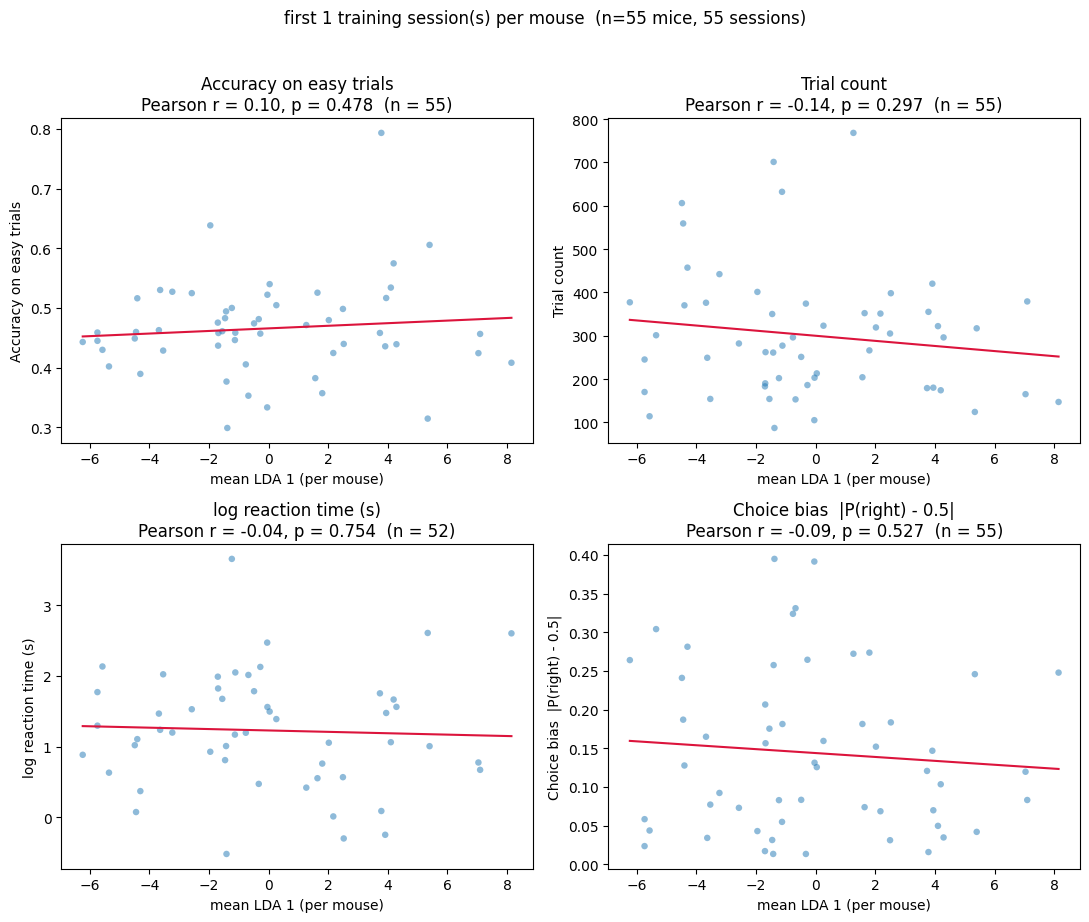

In [30]:
behavior_lda = behavior.merge(mouse_lda, on='mouse_name')

metrics = [('accuracy_easy', 'Accuracy on easy trials'),
           ('trial_count',   'Trial count'),
           ('log_reaction',  'log reaction time (s)'),
           ('choice_bias',   'Choice bias  |P(right) - 0.5|')]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (col, label) in zip(axes.flat, metrics):
    d = behavior_lda[['lda_1', col]].dropna()
    x, y = d['lda_1'].values, d[col].values
    ax.scatter(x, y, s=22, alpha=0.5, edgecolor='none')   # each session is a dot
    if len(d) > 2:
        r, p = pearsonr(x, y)
        slope, intercept = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, intercept + slope * xs, color='crimson', lw=1.5)
        ax.set_title(f'{label}\nPearson r = {r:.2f}, p = {p:.3g}  (n = {len(d)})')
    else:
        ax.set_title(label)
    ax.set_xlabel('mean LDA 1 (per mouse)')
    ax.set_ylabel(label)

fig.suptitle(f'{WHICH} {N_SESSIONS} training session(s) per mouse  (n={behavior_lda["mouse_name"].nunique()} mice, {len(behavior_lda)} sessions)', y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# Save the per-mouse behaviour table
# behavior_lda.to_csv('first_session_behavior.csv', index=False)
# print('Saved first_session_behavior.csv')